# PUC-Rio — Redes Neurais
## Mapa Auto-Organizável (SOM) — Implementação em PyTorch

**Neste notebook, abordaremos:**
1. **Implementação completa do SOM** em PyTorch, com suporte a aceleração por tensores.
2. **Topologias Hexagonal e Retangular** e seus impactos visuais e de vizinhança.
3. **Funções de Decaimento e Vizinhança** (Gaussiana, Bolha, Chapéu Mexicano).
4. **Treinamento em Duas Fases**: ordenação global + ajuste fino.
5. **Visualizações Profissionais**: U-Matrix, Planos de Componentes, Hit Map, Mapa de Países e Vetores de Pesos (PCA → RGB).
6. **Exploração Interativa**: delimitação manual de clusters com Plotly.
7. **Agrupamento Automático**: K-Means sobre os pesos do SOM + análise de pureza.

---

### Introdução Teórica

O **Mapa Auto-Organizável (SOM)**, introduzido por Teuvo Kohonen em 1982, é uma rede neural
treinada por aprendizado **não supervisionado** para produzir uma representação discretizada
(geralmente bidimensional) do espaço de entrada das amostras de treinamento.

O algoritmo opera por **aprendizado competitivo**: os neurônios competem pelo privilégio de
responder a cada entrada. O neurônio vencedor (**Best Matching Unit — BMU**) e seus vizinhos
na grade têm seus pesos ajustados em direção ao vetor de entrada, com intensidade controlada
pela **taxa de aprendizado** ($\eta$) e pela **função de vizinhança** ($h$), que decaem ao longo
do treinamento.

In [52]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from collections import defaultdict
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# ── Estilo profissional ──
plt.rcParams.update({
    'figure.figsize': (10, 8),
    'figure.dpi': 150,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': False,
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 15,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'legend.framealpha': 0.95,
    'legend.edgecolor': '#dddddd',
})

print('Bibliotecas carregadas com sucesso!')
print(f'PyTorch versao: {torch.__version__}')

Bibliotecas carregadas com sucesso!
PyTorch versao: 2.9.1+cpu


In [53]:
class SelfOrganizingMap:
    """
    Implementacao completa de um Mapa Auto-Organizavel (SOM) em PyTorch.
    Suporta topologias retangular e hexagonal, multiplas funcoes de
    vizinhanca e decaimento, e visualizacoes profissionais.
    """

    def __init__(self, m, n, input_dim, topology='rectangular',
                 neighborhood_fn='gaussian', decay_fn='exponential',
                 init_method='pca', random_seed=42):
        self.m = m
        self.n = n
        self.input_dim = input_dim
        self.topology = topology
        self.neighborhood_fn_name = neighborhood_fn
        self.decay_fn_name = decay_fn
        self.init_method = init_method
        self.n_neurons = m * n

        torch.manual_seed(random_seed)
        np.random.seed(random_seed)

        self.grid_positions = self._compute_grid_positions()
        self.pairwise_distances = torch.cdist(
            self.grid_positions.unsqueeze(0),
            self.grid_positions.unsqueeze(0)
        ).squeeze(0)

        self.weights = None
        self._total_iterations = 0
        self.history = {
            'iteration': [], 'qe': [], 'te': [], 'lr': [], 'sigma': []
        }
        self.phase_boundaries = []

    # ═══════════ TOPOLOGY ═══════════

    def _compute_grid_positions(self):
        positions = torch.zeros(self.n_neurons, 2)
        for i in range(self.m):
            for j in range(self.n):
                k = i * self.n + j
                if self.topology == 'hexagonal':
                    positions[k, 0] = j + 0.5 * (i % 2)
                    positions[k, 1] = i * np.sqrt(3) / 2
                else:
                    positions[k, 0] = float(j)
                    positions[k, 1] = float(i)
        return positions

    def _get_neighbors(self, idx):
        i = idx // self.n
        j = idx % self.n
        neighbors = []
        if self.topology == 'rectangular':
            for di, dj in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                ni, nj = i + di, j + dj
                if 0 <= ni < self.m and 0 <= nj < self.n:
                    neighbors.append(ni * self.n + nj)
        else:
            if i % 2 == 0:
                offsets = [(-1, -1), (-1, 0), (0, -1), (0, 1), (1, -1), (1, 0)]
            else:
                offsets = [(-1, 0), (-1, 1), (0, -1), (0, 1), (1, 0), (1, 1)]
            for di, dj in offsets:
                ni, nj = i + di, j + dj
                if 0 <= ni < self.m and 0 <= nj < self.n:
                    neighbors.append(ni * self.n + nj)
        return neighbors

    def _neuron_xy(self, k):
        """Coordenadas (x, y) do neuronio k na grade."""
        i, j = k // self.n, k % self.n
        if self.topology == 'hexagonal':
            return j + 0.5 * (i % 2), i * np.sqrt(3) / 2
        return float(j), float(i)

    def _hex_vertices(self, cx, cy):
        """Vertices de um hexagono pointy-top centrado em (cx, cy).

        Para a grade com espacamento horizontal = 1 e vertical = sqrt(3)/2,
        o raio circunscrito eh R = 1/sqrt(3).  Os vertices ficam em angulos
        30, 90, 150, 210, 270, 330 graus, o que produz arestas verticais
        entre vizinhos horizontais e encaixe perfeito na grade offset.
        """
        R = 1.0 / np.sqrt(3)
        angles = [np.pi / 6 + k * np.pi / 3 for k in range(6)]
        return [(cx + R * np.cos(a), cy + R * np.sin(a)) for a in angles]

    # ═══════════ INITIALIZATION ═══════════

    def initialize(self, data):
        if self.init_method == 'pca':
            self._init_weights_pca(data)
        else:
            self._init_weights_random(data)

    def _init_weights_random(self, data):
        lo = data.min(dim=0).values
        hi = data.max(dim=0).values
        self.weights = lo + torch.rand(self.n_neurons, self.input_dim) * (hi - lo)

    def _init_weights_pca(self, data):
        mean = data.mean(dim=0)
        centered = data - mean
        cov = (centered.T @ centered) / (len(data) - 1)
        eigenvalues, eigenvectors = torch.linalg.eigh(cov)
        idx = torch.argsort(eigenvalues, descending=True)
        eigenvalues = eigenvalues[idx].clamp(min=0)
        eigenvectors = eigenvectors[:, idx]
        pc1 = eigenvectors[:, 0]
        pc2 = eigenvectors[:, 1] if self.input_dim >= 2 else torch.zeros_like(pc1)
        self.weights = torch.zeros(self.n_neurons, self.input_dim)
        for k in range(self.n_neurons):
            c1 = (2.0 * (k // self.n) / max(self.m - 1, 1)) - 1.0
            c2 = (2.0 * (k % self.n) / max(self.n - 1, 1)) - 1.0
            self.weights[k] = (mean
                               + c1 * torch.sqrt(eigenvalues[0]) * pc1
                               + c2 * torch.sqrt(eigenvalues[1]) * pc2)

    # ═══════════ NEIGHBORHOOD ═══════════

    def _neighborhood(self, bmu_idx, sigma):
        d = self.pairwise_distances[bmu_idx]
        if self.neighborhood_fn_name == 'gaussian':
            return torch.exp(-d ** 2 / (2 * sigma ** 2))
        elif self.neighborhood_fn_name == 'bubble':
            return (d <= sigma).float()
        elif self.neighborhood_fn_name == 'mexican_hat':
            d2s2 = d ** 2 / (sigma ** 2)
            return (1 - d2s2) * torch.exp(-d2s2 / 2)
        raise ValueError(f"Vizinhanca desconhecida: {self.neighborhood_fn_name}")

    # ═══════════ DECAY ═══════════

    def _decay(self, start, end, step, total_steps):
        if total_steps == 0:
            return start
        t = step / total_steps
        if self.decay_fn_name == 'linear':
            return start + (end - start) * t
        elif self.decay_fn_name == 'exponential':
            return start * (max(end, 1e-8) / start) ** t
        elif self.decay_fn_name == 'inverse':
            return start / (1 + step * (start / max(end, 1e-8) - 1) / total_steps)
        raise ValueError(f"Decaimento desconhecido: {self.decay_fn_name}")

    # ═══════════ TRAINING ═══════════

    def _find_bmu(self, x):
        return torch.argmin(torch.norm(self.weights - x, dim=1))

    @torch.no_grad()
    def train(self, data, n_iterations, lr_start, lr_end,
              sigma_start, sigma_end, phase_name='',
              eval_every=100, verbose=True):
        n_samples = len(data)
        pbar = tqdm(range(n_iterations), desc=phase_name, disable=not verbose)
        for step in pbar:
            x = data[np.random.randint(n_samples)]
            lr = self._decay(lr_start, lr_end, step, n_iterations)
            sigma = self._decay(sigma_start, sigma_end, step, n_iterations)
            bmu = self._find_bmu(x)
            h = self._neighborhood(bmu, sigma)
            self.weights += lr * h.unsqueeze(1) * (x - self.weights)
            if (step + 1) % eval_every == 0 or step == n_iterations - 1:
                qe = self.quantization_error(data)
                te = self.topographic_error(data)
                self.history['iteration'].append(self._total_iterations + step + 1)
                self.history['qe'].append(qe)
                self.history['te'].append(te)
                self.history['lr'].append(lr)
                self.history['sigma'].append(sigma)
                if verbose:
                    pbar.set_postfix({'QE': f'{qe:.4f}', 'TE': f'{te:.4f}'})
        self._total_iterations += n_iterations
        self.phase_boundaries.append((phase_name, self._total_iterations))

    # ═══════════ METRICS ═══════════

    def quantization_error(self, data):
        return torch.cdist(data, self.weights).min(dim=1).values.mean().item()

    def topographic_error(self, data):
        dists = torch.cdist(data, self.weights)
        top2 = torch.topk(dists, 2, dim=1, largest=False)
        bmu1, bmu2 = top2.indices[:, 0], top2.indices[:, 1]
        return (self.pairwise_distances[bmu1, bmu2] > 1.1).float().mean().item()

    def compute_umatrix(self):
        u = torch.zeros(self.n_neurons)
        for k in range(self.n_neurons):
            nbs = self._get_neighbors(k)
            if nbs:
                u[k] = torch.norm(self.weights[k] - self.weights[nbs], dim=1).mean()
        return u

    # ═══════════ VISUALIZATION CORE ═══════════

    def _setup_hex_axes(self, ax):
        R = 1.0 / np.sqrt(3)
        pad = 0.15
        x_lo = -R - pad
        x_hi = (self.n - 1) + 0.5 + R + pad
        y_lo = -R - pad
        y_hi = (self.m - 1) * np.sqrt(3) / 2 + R + pad
        ax.set_xlim(x_lo, x_hi)
        ax.set_ylim(y_hi, y_lo)          # inverted
        ax.set_aspect('equal')

    def _plot_grid(self, values, title='', cmap='viridis', ax=None,
                   colorbar=True, vmin=None, vmax=None):
        """Plota valores na grade do SOM (retangular ou hexagonal)."""
        if isinstance(values, torch.Tensor):
            values = values.numpy()
        own_fig = ax is None
        if ax is None:
            fig, ax = plt.subplots(figsize=(10, 9))
        vmin = vmin if vmin is not None else values.min()
        vmax = vmax if vmax is not None else values.max()
        norm = plt.Normalize(vmin=vmin, vmax=vmax)
        cmap_obj = plt.cm.get_cmap(cmap)

        if self.topology == 'rectangular':
            grid = values.reshape(self.m, self.n)
            im = ax.pcolormesh(
                np.arange(self.n + 1) - 0.5,
                np.arange(self.m + 1) - 0.5,
                grid, cmap=cmap, vmin=vmin, vmax=vmax,
                edgecolors='#eeeeee', linewidth=0.5, shading='flat')
            ax.set_xlim(-0.5, self.n - 0.5)
            ax.set_ylim(self.m - 0.5, -0.5)
            ax.set_aspect('equal')
        else:
            patches_list = []
            colors_list = []
            for k in range(self.n_neurons):
                verts = self._hex_vertices(*self._neuron_xy(k))
                patches_list.append(Polygon(verts, closed=True))
                colors_list.append(cmap_obj(norm(values[k])))
            coll = PatchCollection(patches_list, match_original=False)
            coll.set_facecolors(colors_list)
            coll.set_edgecolors('white')
            coll.set_linewidths(0.8)
            coll.set_zorder(1)
            ax.add_collection(coll)
            self._setup_hex_axes(ax)

        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)

        if colorbar:
            if self.topology == 'rectangular':
                cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            else:
                sm = plt.cm.ScalarMappable(cmap=cmap_obj, norm=norm)
                sm.set_array([])
                cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
            cbar.ax.tick_params(labelsize=10)

        if title:
            ax.set_title(title, fontsize=14, fontweight='bold', pad=12)
        return ax

    # ═══════════ VISUALIZATIONS ═══════════

    def plot_umatrix(self, ax=None):
        return self._plot_grid(self.compute_umatrix(),
                               title='U-Matrix', cmap='RdYlBu_r', ax=ax)

    def plot_component_planes(self, feature_names=None):
        nf = self.input_dim
        if feature_names is None:
            feature_names = [f'Feature {i}' for i in range(nf)]
        ncols = min(3, nf)
        nrows = int(np.ceil(nf / ncols))
        fig, axes = plt.subplots(nrows, ncols,
                                 figsize=(5.5 * ncols, 5 * nrows))
        axes = np.array(axes).flatten()
        for i in range(nf):
            vals = self.weights[:, i].detach().numpy()
            self._plot_grid(vals, title=feature_names[i],
                            cmap='coolwarm', ax=axes[i])
        for i in range(nf, len(axes)):
            axes[i].set_visible(False)
        fig.suptitle('Planos de Componentes',
                     fontsize=16, fontweight='bold', y=1.01)
        plt.tight_layout()
        plt.show()

    def plot_hit_map(self, data, ax=None):
        bmus = torch.argmin(torch.cdist(data, self.weights), dim=1)
        hits = torch.zeros(self.n_neurons)
        for b in bmus:
            hits[b] += 1
        show = ax is None
        if ax is None:
            fig, ax = plt.subplots(figsize=(10, 9))
        self._plot_grid(hits, title='Mapa de Ativacao (Hit Map)',
                        cmap='YlOrRd', ax=ax)
        max_h = max(hits.max().item(), 1)
        for k in range(self.n_neurons):
            if hits[k] > 0:
                x, y = self._neuron_xy(k)
                r = 0.25 * np.sqrt(hits[k].item() / max_h) + 0.05
                circle = plt.Circle((x, y), r, facecolor='white',
                                    edgecolor='#333333', linewidth=0.8,
                                    alpha=0.85, zorder=3)
                ax.add_patch(circle)
                ax.text(x, y, f'{int(hits[k])}', ha='center', va='center',
                        fontsize=6, fontweight='bold', color='#333333',
                        zorder=4)
        if show:
            plt.tight_layout()
            plt.show()
        return ax

    def plot_winner_map(self, data, labels, colors_dict=None,
                        country_codes=None, category_color=None):
        fig, ax = plt.subplots(figsize=(14, 12))
        umatrix = self.compute_umatrix()
        self._plot_grid(umatrix, cmap='bone_r', ax=ax, colorbar=False)
        bmus = torch.argmin(torch.cdist(data, self.weights), dim=1)
        bmu_labels = defaultdict(list)
        for idx_s, bmu in enumerate(bmus):
            bmu_labels[bmu.item()].append(labels[idx_s])
        for bmu_idx, label_list in bmu_labels.items():
            x, y = self._neuron_xy(bmu_idx)
            for kk, label in enumerate(label_list):
                display = label
                if country_codes and len(label) > 6:
                    display = country_codes.get(label, label[:6])
                color = colors_dict.get(label, 'black') if colors_dict else 'black'
                y_off = (kk - len(label_list) / 2 + 0.5) * 0.12
                ax.text(x, y + y_off, display, ha='center', va='center',
                        fontsize=5.5, fontweight='bold', color=color,
                        path_effects=[pe.withStroke(linewidth=2,
                                                    foreground='white')],
                        zorder=5)
        if category_color:
            handles = [mpatches.Patch(color=c, label=cat)
                       for cat, c in category_color.items()]
            ax.legend(handles=handles, loc='upper left', fontsize=10,
                      framealpha=0.95, title='Categoria',
                      title_fontsize=11)
        ax.set_title('Mapa de Paises', fontsize=16,
                     fontweight='bold', pad=12)
        plt.tight_layout()
        plt.show()

    def plot_weight_vectors(self):
        pca = PCA(n_components=3)
        w3d = pca.fit_transform(self.weights.detach().numpy())
        wmin, wmax = w3d.min(axis=0), w3d.max(axis=0)
        rng = wmax - wmin
        rng[rng == 0] = 1
        w_rgb = (w3d - wmin) / rng
        fig, ax = plt.subplots(figsize=(10, 9))
        if self.topology == 'rectangular':
            ax.imshow(w_rgb.reshape(self.m, self.n, 3),
                      interpolation='nearest')
        else:
            for k in range(self.n_neurons):
                verts = self._hex_vertices(*self._neuron_xy(k))
                patch = Polygon(verts, closed=True,
                                facecolor=w_rgb[k],
                                edgecolor='white', linewidth=0.8, zorder=1)
                ax.add_patch(patch)
            self._setup_hex_axes(ax)
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
        ax.set_title('Vetores de Peso (PCA -> RGB)',
                     fontsize=14, fontweight='bold', pad=12)
        plt.tight_layout()
        plt.show()

    # ═══════════ TRAINING CURVES ═══════════

    def plot_training_history(self):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        iters = self.history['iteration']
        # QE
        ax1.plot(iters, self.history['qe'],
                 color='#1976D2', linewidth=2.2, alpha=0.9)
        ax1.fill_between(iters, self.history['qe'],
                         alpha=0.06, color='#1976D2')
        ax1.set_title('Erro de Quantizacao')
        ax1.set_xlabel('Iteracao')
        ax1.set_ylabel('QE')
        # TE
        ax2.plot(iters, self.history['te'],
                 color='#D32F2F', linewidth=2.2, alpha=0.9)
        ax2.fill_between(iters, self.history['te'],
                         alpha=0.06, color='#D32F2F')
        ax2.set_title('Erro Topografico')
        ax2.set_xlabel('Iteracao')
        ax2.set_ylabel('TE')
        for name, boundary in self.phase_boundaries[:-1]:
            for a in (ax1, ax2):
                a.axvline(x=boundary, color='#9E9E9E', linestyle='--',
                          alpha=0.7, label=f'Fim: {name}')
        for a in (ax1, ax2):
            a.grid(True, alpha=0.15, linestyle='--')
            a.spines['top'].set_visible(False)
            a.spines['right'].set_visible(False)
            a.legend(framealpha=0.9)
        plt.tight_layout()
        plt.show()

    def plot_decay_curves(self):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        iters = self.history['iteration']
        ax1.plot(iters, self.history['lr'],
                 color='#388E3C', linewidth=2.2, alpha=0.9)
        ax1.fill_between(iters, self.history['lr'],
                         alpha=0.06, color='#388E3C')
        ax1.set_title('Taxa de Aprendizado ($\\eta$)')
        ax1.set_xlabel('Iteracao')
        ax1.set_ylabel('$\\eta$')
        ax2.plot(iters, self.history['sigma'],
                 color='#7B1FA2', linewidth=2.2, alpha=0.9)
        ax2.fill_between(iters, self.history['sigma'],
                         alpha=0.06, color='#7B1FA2')
        ax2.set_title('Raio de Vizinhanca ($\\sigma$)')
        ax2.set_xlabel('Iteracao')
        ax2.set_ylabel('$\\sigma$')
        for name, boundary in self.phase_boundaries[:-1]:
            for a in (ax1, ax2):
                a.axvline(x=boundary, color='#9E9E9E', linestyle='--',
                          alpha=0.7, label=f'Fim: {name}')
        for a in (ax1, ax2):
            a.grid(True, alpha=0.15, linestyle='--')
            a.spines['top'].set_visible(False)
            a.spines['right'].set_visible(False)
            a.legend(framealpha=0.9)
        plt.tight_layout()
        plt.show()

    # ═══════════ CLUSTER MAP ═══════════

    def plot_cluster_map(self, clusters, data=None, labels=None,
                         colors_dict=None, country_codes=None,
                         category_color=None, show_boundaries=True):
        """Mapa do SOM colorido por cluster com fronteiras."""
        n_cl = len(np.unique(clusters))
        cl_cmap = plt.cm.get_cmap('Set2', n_cl)
        fig, ax = plt.subplots(figsize=(14, 12))

        # --- neuronios coloridos por cluster ---
        if self.topology == 'rectangular':
            rgb = np.array([cl_cmap(c)[:3] for c in clusters])
            ax.imshow(rgb.reshape(self.m, self.n, 3), interpolation='nearest')
            ax.set_xlim(-0.5, self.n - 0.5)
            ax.set_ylim(self.m - 0.5, -0.5)
            ax.set_aspect('equal')
        else:
            for k in range(self.n_neurons):
                verts = self._hex_vertices(*self._neuron_xy(k))
                patch = Polygon(verts, closed=True,
                                facecolor=cl_cmap(clusters[k]),
                                edgecolor='white', linewidth=0.8, zorder=1)
                ax.add_patch(patch)
            self._setup_hex_axes(ax)

        # --- fronteiras entre clusters ---
        if show_boundaries:
            R = 1.0 / np.sqrt(3)
            half = R / 2
            drawn = set()
            for k in range(self.n_neurons):
                for nb in self._get_neighbors(k):
                    if clusters[k] != clusters[nb]:
                        edge_key = (min(k, nb), max(k, nb))
                        if edge_key in drawn:
                            continue
                        drawn.add(edge_key)
                        x1, y1 = self._neuron_xy(k)
                        x2, y2 = self._neuron_xy(nb)
                        mx, my = (x1 + x2) / 2, (y1 + y2) / 2
                        dx, dy = x2 - x1, y2 - y1
                        px, py = -dy, dx   # perp (unit, dist=1)
                        ax.plot([mx - half * px, mx + half * px],
                                [my - half * py, my + half * py],
                                color='#333333', linewidth=2.5,
                                solid_capstyle='round', zorder=5)

        # --- rotulos dos paises ---
        if data is not None and labels is not None:
            bmus = torch.argmin(torch.cdist(data, self.weights), dim=1)
            groups = defaultdict(list)
            for idx_s, bmu in enumerate(bmus):
                groups[bmu.item()].append(labels[idx_s])
            for bmu_idx, lbl_list in groups.items():
                x, y = self._neuron_xy(bmu_idx)
                for kk, label in enumerate(lbl_list):
                    display = label
                    if country_codes and len(label) > 6:
                        display = country_codes.get(label, label[:6])
                    color = (colors_dict.get(label, 'black')
                             if colors_dict else 'black')
                    y_off = (kk - len(lbl_list) / 2 + 0.5) * 0.12
                    ax.text(x, y + y_off, display,
                            ha='center', va='center',
                            fontsize=5.5, fontweight='bold', color=color,
                            path_effects=[pe.withStroke(linewidth=2,
                                                        foreground='white')],
                            zorder=6)

        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)

        handles = [mpatches.Patch(color=cl_cmap(c), label=f'Cluster {c+1}')
                   for c in range(n_cl)]
        if category_color:
            handles += [mpatches.Patch(facecolor='white', edgecolor=c,
                                       linewidth=2, label=cat)
                        for cat, c in category_color.items()]
        ax.legend(handles=handles, loc='upper left', fontsize=10,
                  framealpha=0.95, title='Legenda', title_fontsize=11)
        ax.set_title('Mapa de Clusters (K-Means no SOM)',
                     fontsize=16, fontweight='bold', pad=12)
        plt.tight_layout()
        plt.show()

## 1. Carregamento dos Dados — Democracy Index

Vamos aplicar o SOM ao **Índice de Democracia** (*The Economist Intelligence Unit*),
que classifica os países em quatro categorias: *Full democracy*, *Flawed democracy*,
*Hybrid regime* e *Authoritarian regime*.

In [ ]:
democracy_index = pd.read_csv('https://raw.githubusercontent.com/mdrs-thiago/PUC_Redes_Neurais/refs/heads/main/datasets/democracy_index.csv')
display(democracy_index.head(10))
print(f'Shape: {democracy_index.shape}')

,Unnamed: 0,rank,country,democracy_index,electoral_processand_pluralism,functioning_of_government,political_participation,political_culture,civil_liberties,category
0,0,1,Norway,9.87,10.00,9.64,10.00,10.00,9.71,Full democracy
1,1,2,Iceland,9.58,10.00,9.29,8.89,10.00,9.71,Full democracy
2,2,3,Sweden,9.39,9.58,9.64,8.33,10.00,9.41,Full democracy
3,3,4,New Zealand,9.26,10.00,9.29,8.89,8.13,10.00,Full democracy
4,4,5,Denmark,9.22,10.00,9.29,8.33,9.38,9.12,Full democracy
5,5,=6,Ireland,9.15,9.58,7.86,8.33,10.00,10.00,Full democracy
6,6,=6,Canada,9.15,9.58,9.64,7.78,8.75,10.00,Full democracy
7,7,8,Finland,9.14,10.00,8.93,8.33,8.75,9.71,Full democracy
8,8,9,Australia,9.09,10.00,8.93,7.78,8.75,10.00,Full democracy
9,9,10,Switzerland,9.03,9.58,9.29,7.78,9.38,9.12,Full democracy


Shape: (167, 10)


In [57]:
# features = democracy_index.columns[2:]
features = ['electoral_processand_pluralism',
 'functioning_of_government',
 'political_participation',
 'political_culture',
 'civil_liberties']
X = democracy_index[features].values
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_tensor = torch.FloatTensor(X_scaled)
labels = democracy_index.country.tolist()

category_color = {
    'Full democracy':       '#1b5e20',
    'Flawed democracy':     '#8bc34a',
    'Hybrid regime':        '#ffeb3b',
    'Authoritarian': '#d32f2f',
}
colors_dict = {
    row['country']: category_color[row['category']]
    for _, row in democracy_index.iterrows()
}

country_codes = {
    'United Kingdom': 'UK', 'United States': 'USA',
    'United Arab Emirates': 'UAE', 'Saudi Arabia': 'SAU',
    'South Africa': 'ZAF', 'New Zealand': 'NZL',
    'South Korea': 'KOR', 'North Korea': 'PRK',
    'Czech Republic': 'CZE', 'Dominican Republic': 'DOM',
    'Papua New Guinea': 'PNG', 'Trinidad and Tobago': 'TTO',
    'Burkina Faso': 'BFA', 'Sierra Leone': 'SLE',
    'Ivory Coast': 'CIV', 'Equatorial Guinea': 'GNQ',
    'Central African Republic': 'CAF',
    'Republic of the Congo': 'COG',
    'Democratic Republic of the Congo': 'COD',
    'Bosnia and Herzegovina': 'BIH',
}

print(f'Dados: {X_tensor.shape[0]} paises, {X_tensor.shape[1]} features')
print(f'Features: {list(features)}')

Dados: 167 paises, 5 features
Features: ['electoral_processand_pluralism', 'functioning_of_government', 'political_participation', 'political_culture', 'civil_liberties']


## 2. Criação e Treinamento do SOM — Topologia Hexagonal

Utilizamos **duas fases** de treinamento:
1. **Fase de Ordenação** — taxa de aprendizado e raio de vizinhança elevados para
   organização global do mapa.
2. **Fase de Ajuste Fino** — parâmetros reduzidos para refinar o mapeamento local.

In [58]:
m, n = 12, 12
som = SelfOrganizingMap(
    m=m, n=n, input_dim=X_tensor.shape[1],
    topology='hexagonal', neighborhood_fn='gaussian',
    init_method='pca', random_seed=42
)
som.initialize(X_tensor)

# Fase 1: Ordenacao global
som.train(X_tensor, n_iterations=1000,
          lr_start=0.5, lr_end=0.01,
          sigma_start=max(m, n) / 2, sigma_end=1.0,
          phase_name='Fase 1: Ordenacao', eval_every=50)

# Fase 2: Ajuste fino
som.train(X_tensor, n_iterations=5000,
          lr_start=0.01, lr_end=0.001,
          sigma_start=1.0, sigma_end=0.5,
          phase_name='Fase 2: Ajuste Fino', eval_every=50)

Fase 2: Ajuste Fino: 100%|██████████| 5000/5000 [00:01<00:00, 4017.89it/s, QE=0.1377, TE=0.0299]


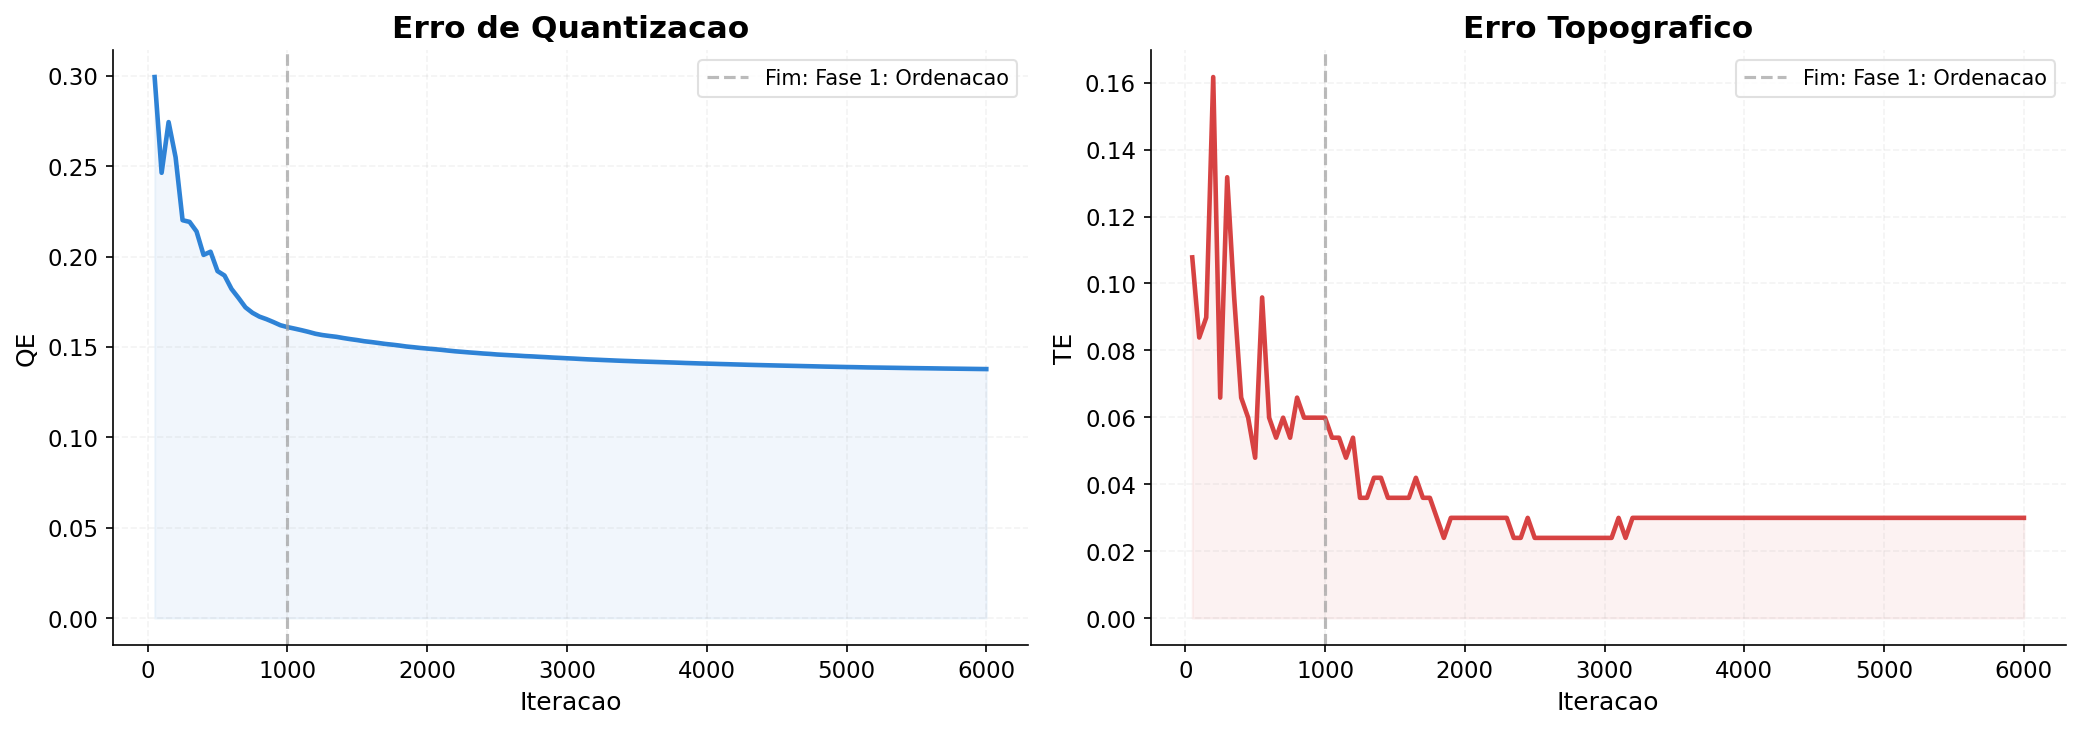

In [59]:
som.plot_training_history()

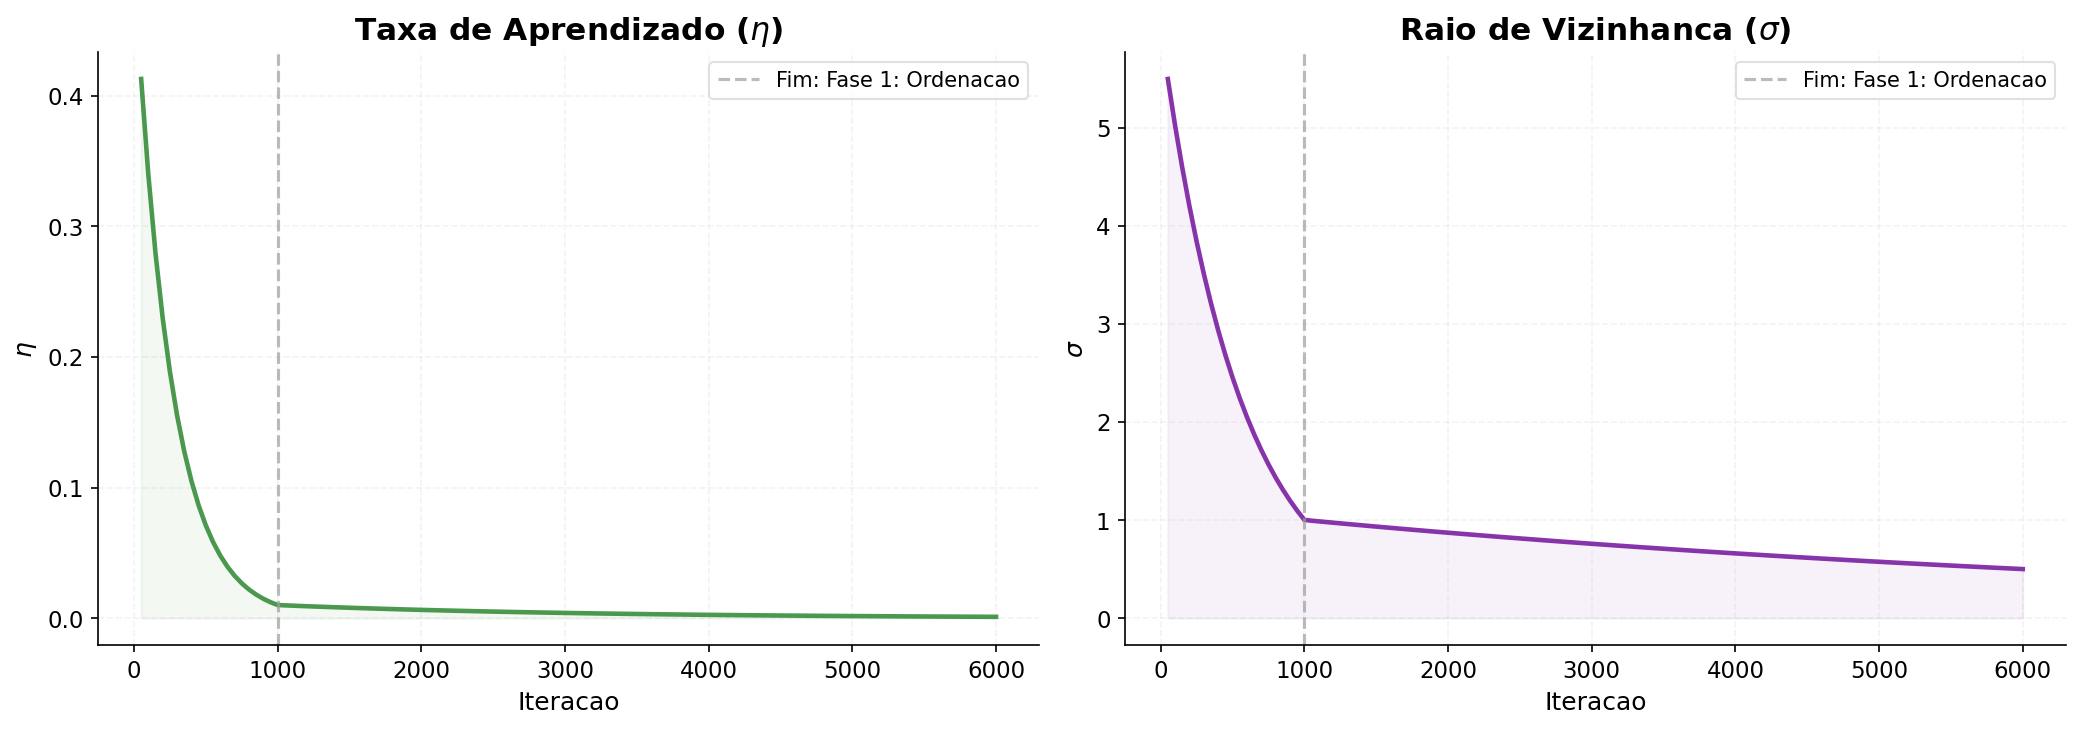

In [60]:
som.plot_decay_curves()

## 3. Visualizações do Mapa Treinado

<Axes: title={'center': 'U-Matrix'}>

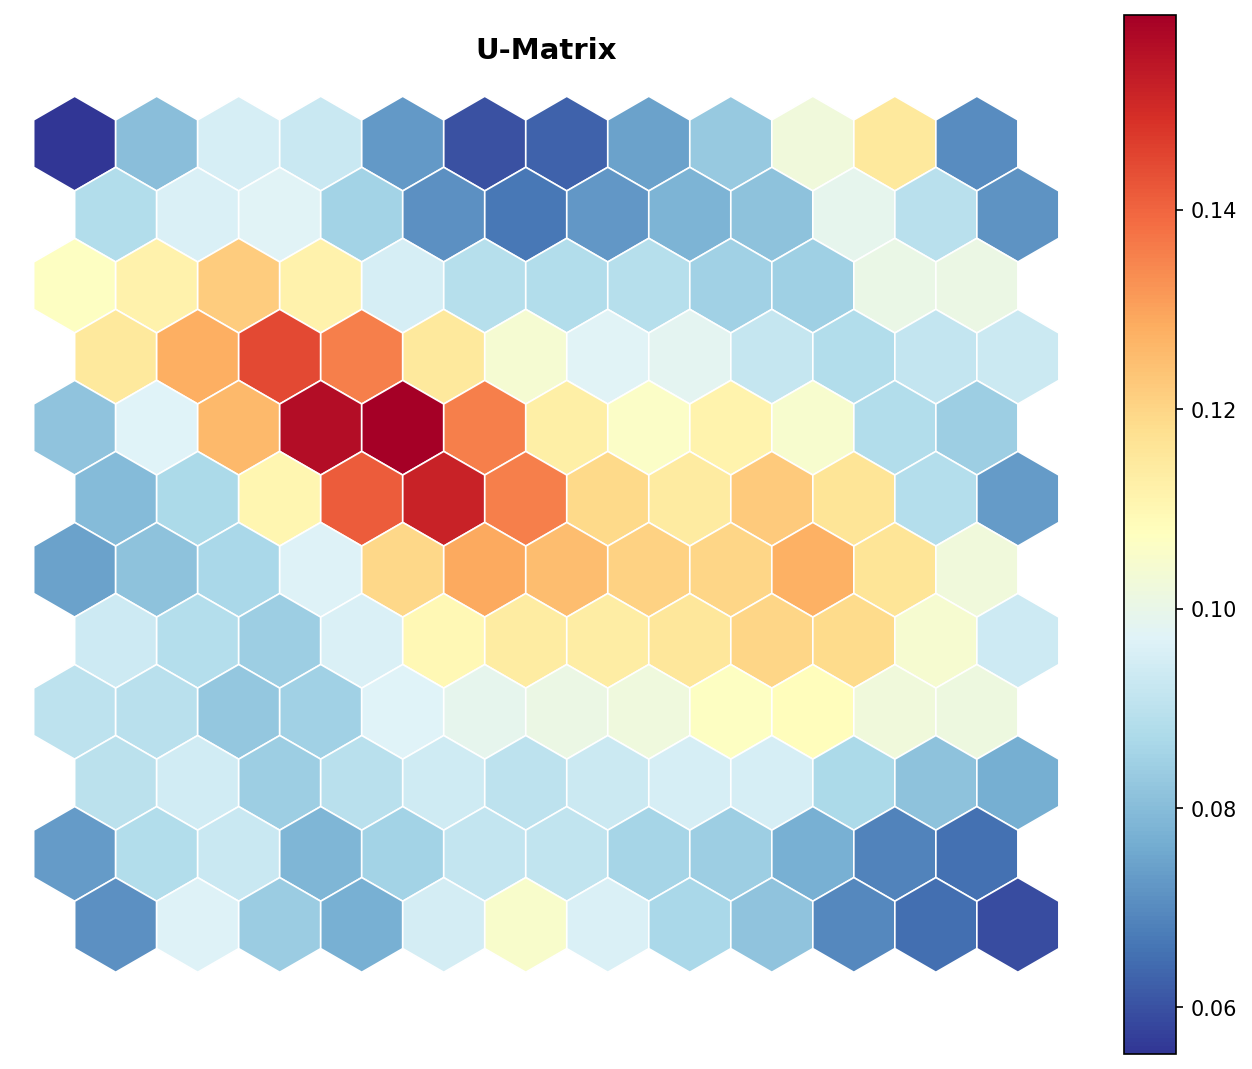

In [61]:
som.plot_umatrix()

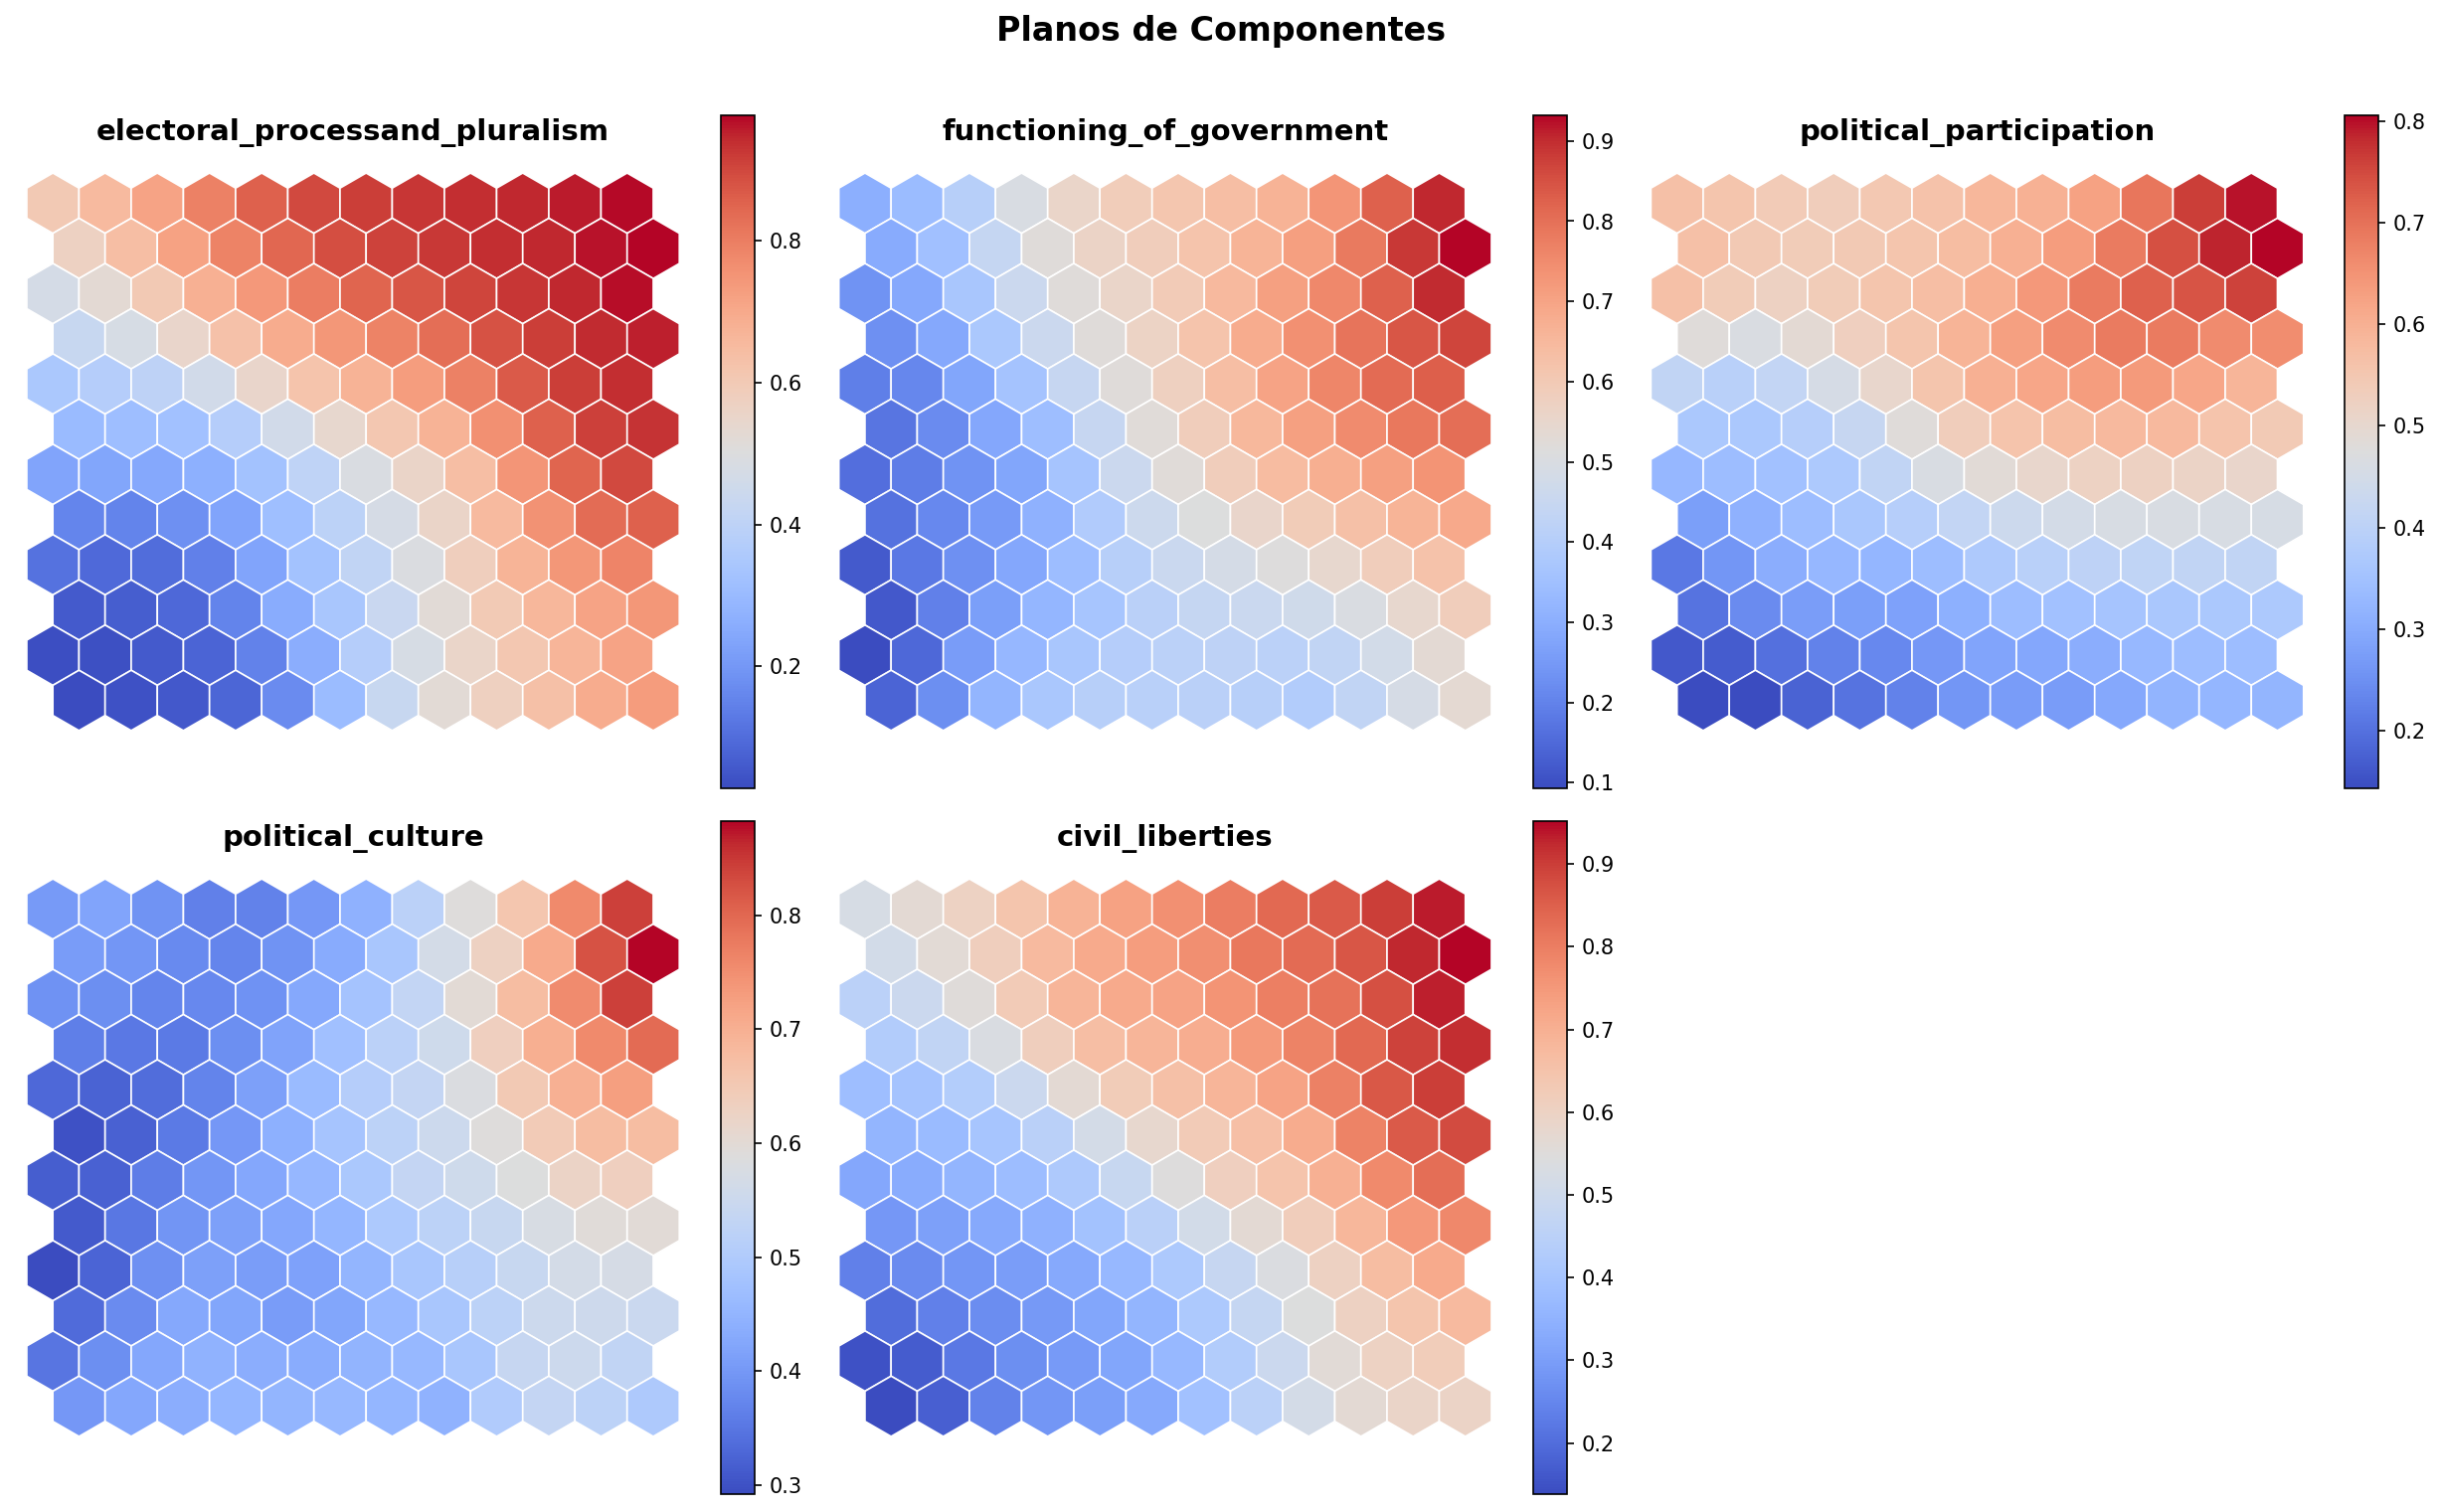

In [63]:
som.plot_component_planes(feature_names=features)

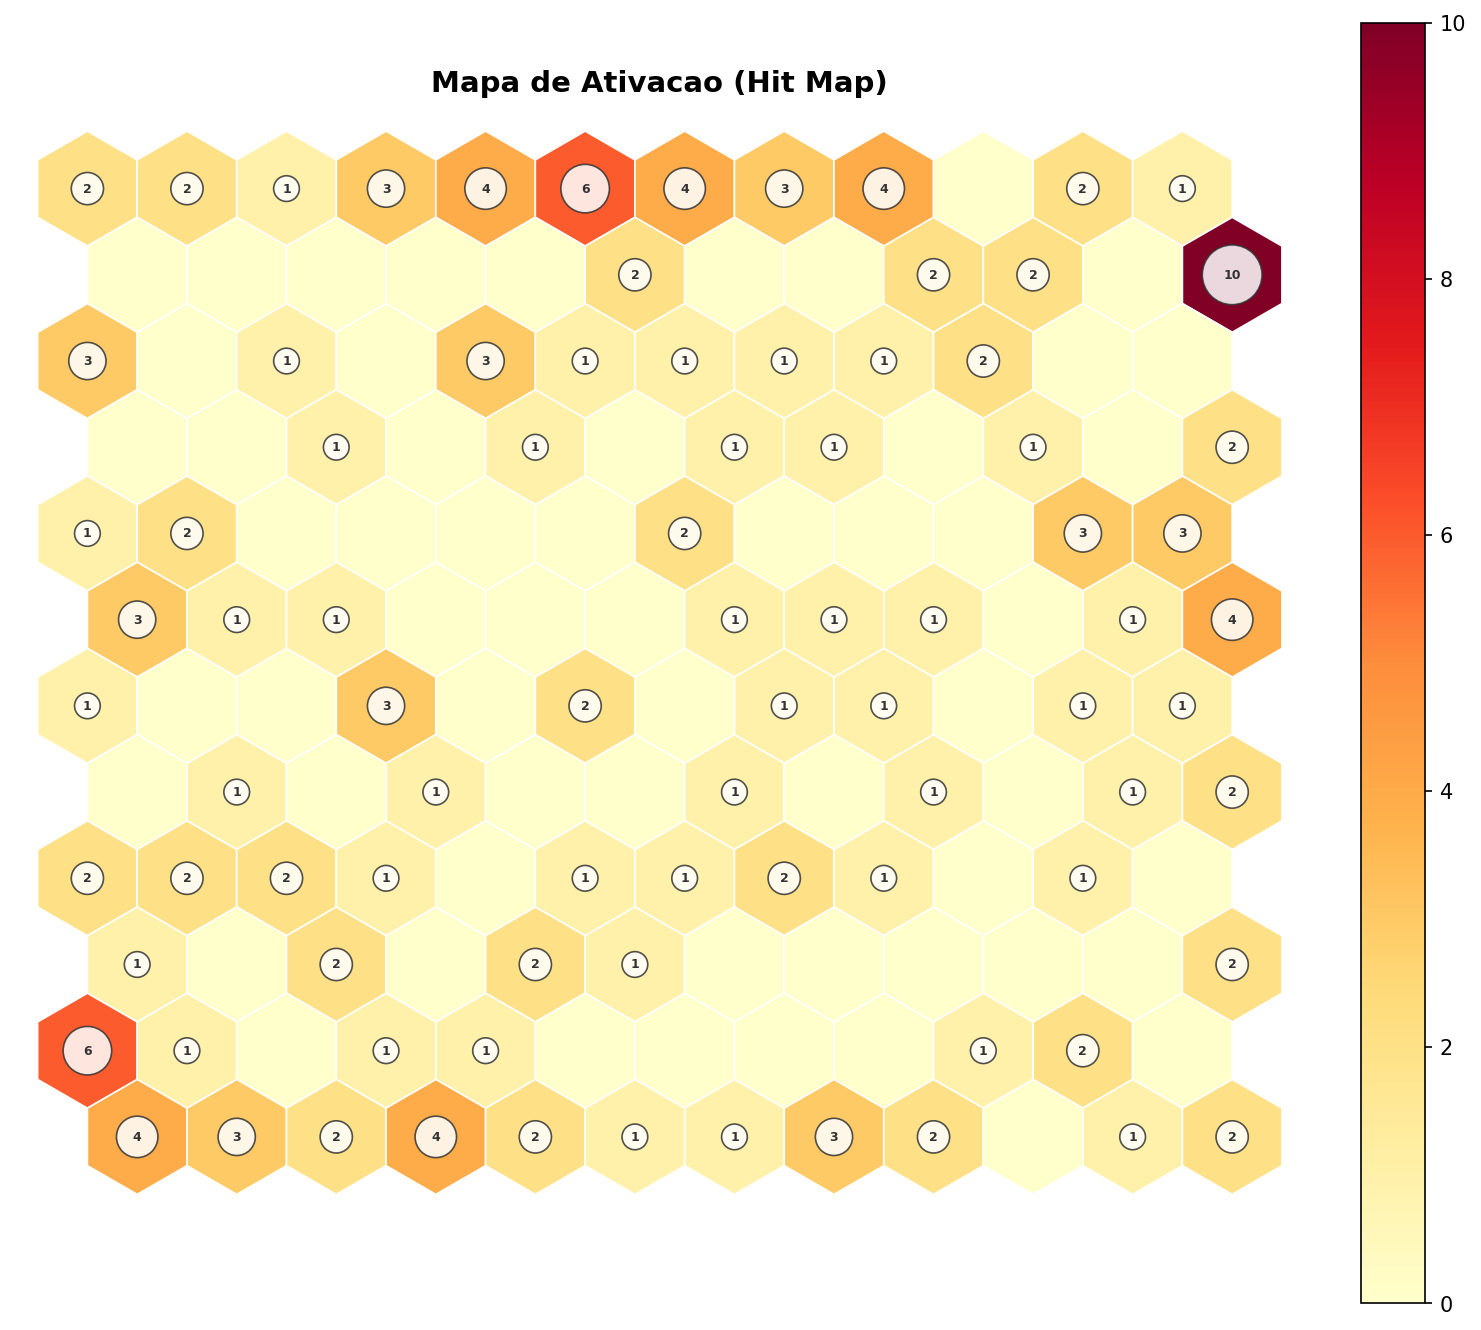

<Axes: title={'center': 'Mapa de Ativacao (Hit Map)'}>

In [64]:
som.plot_hit_map(X_tensor)

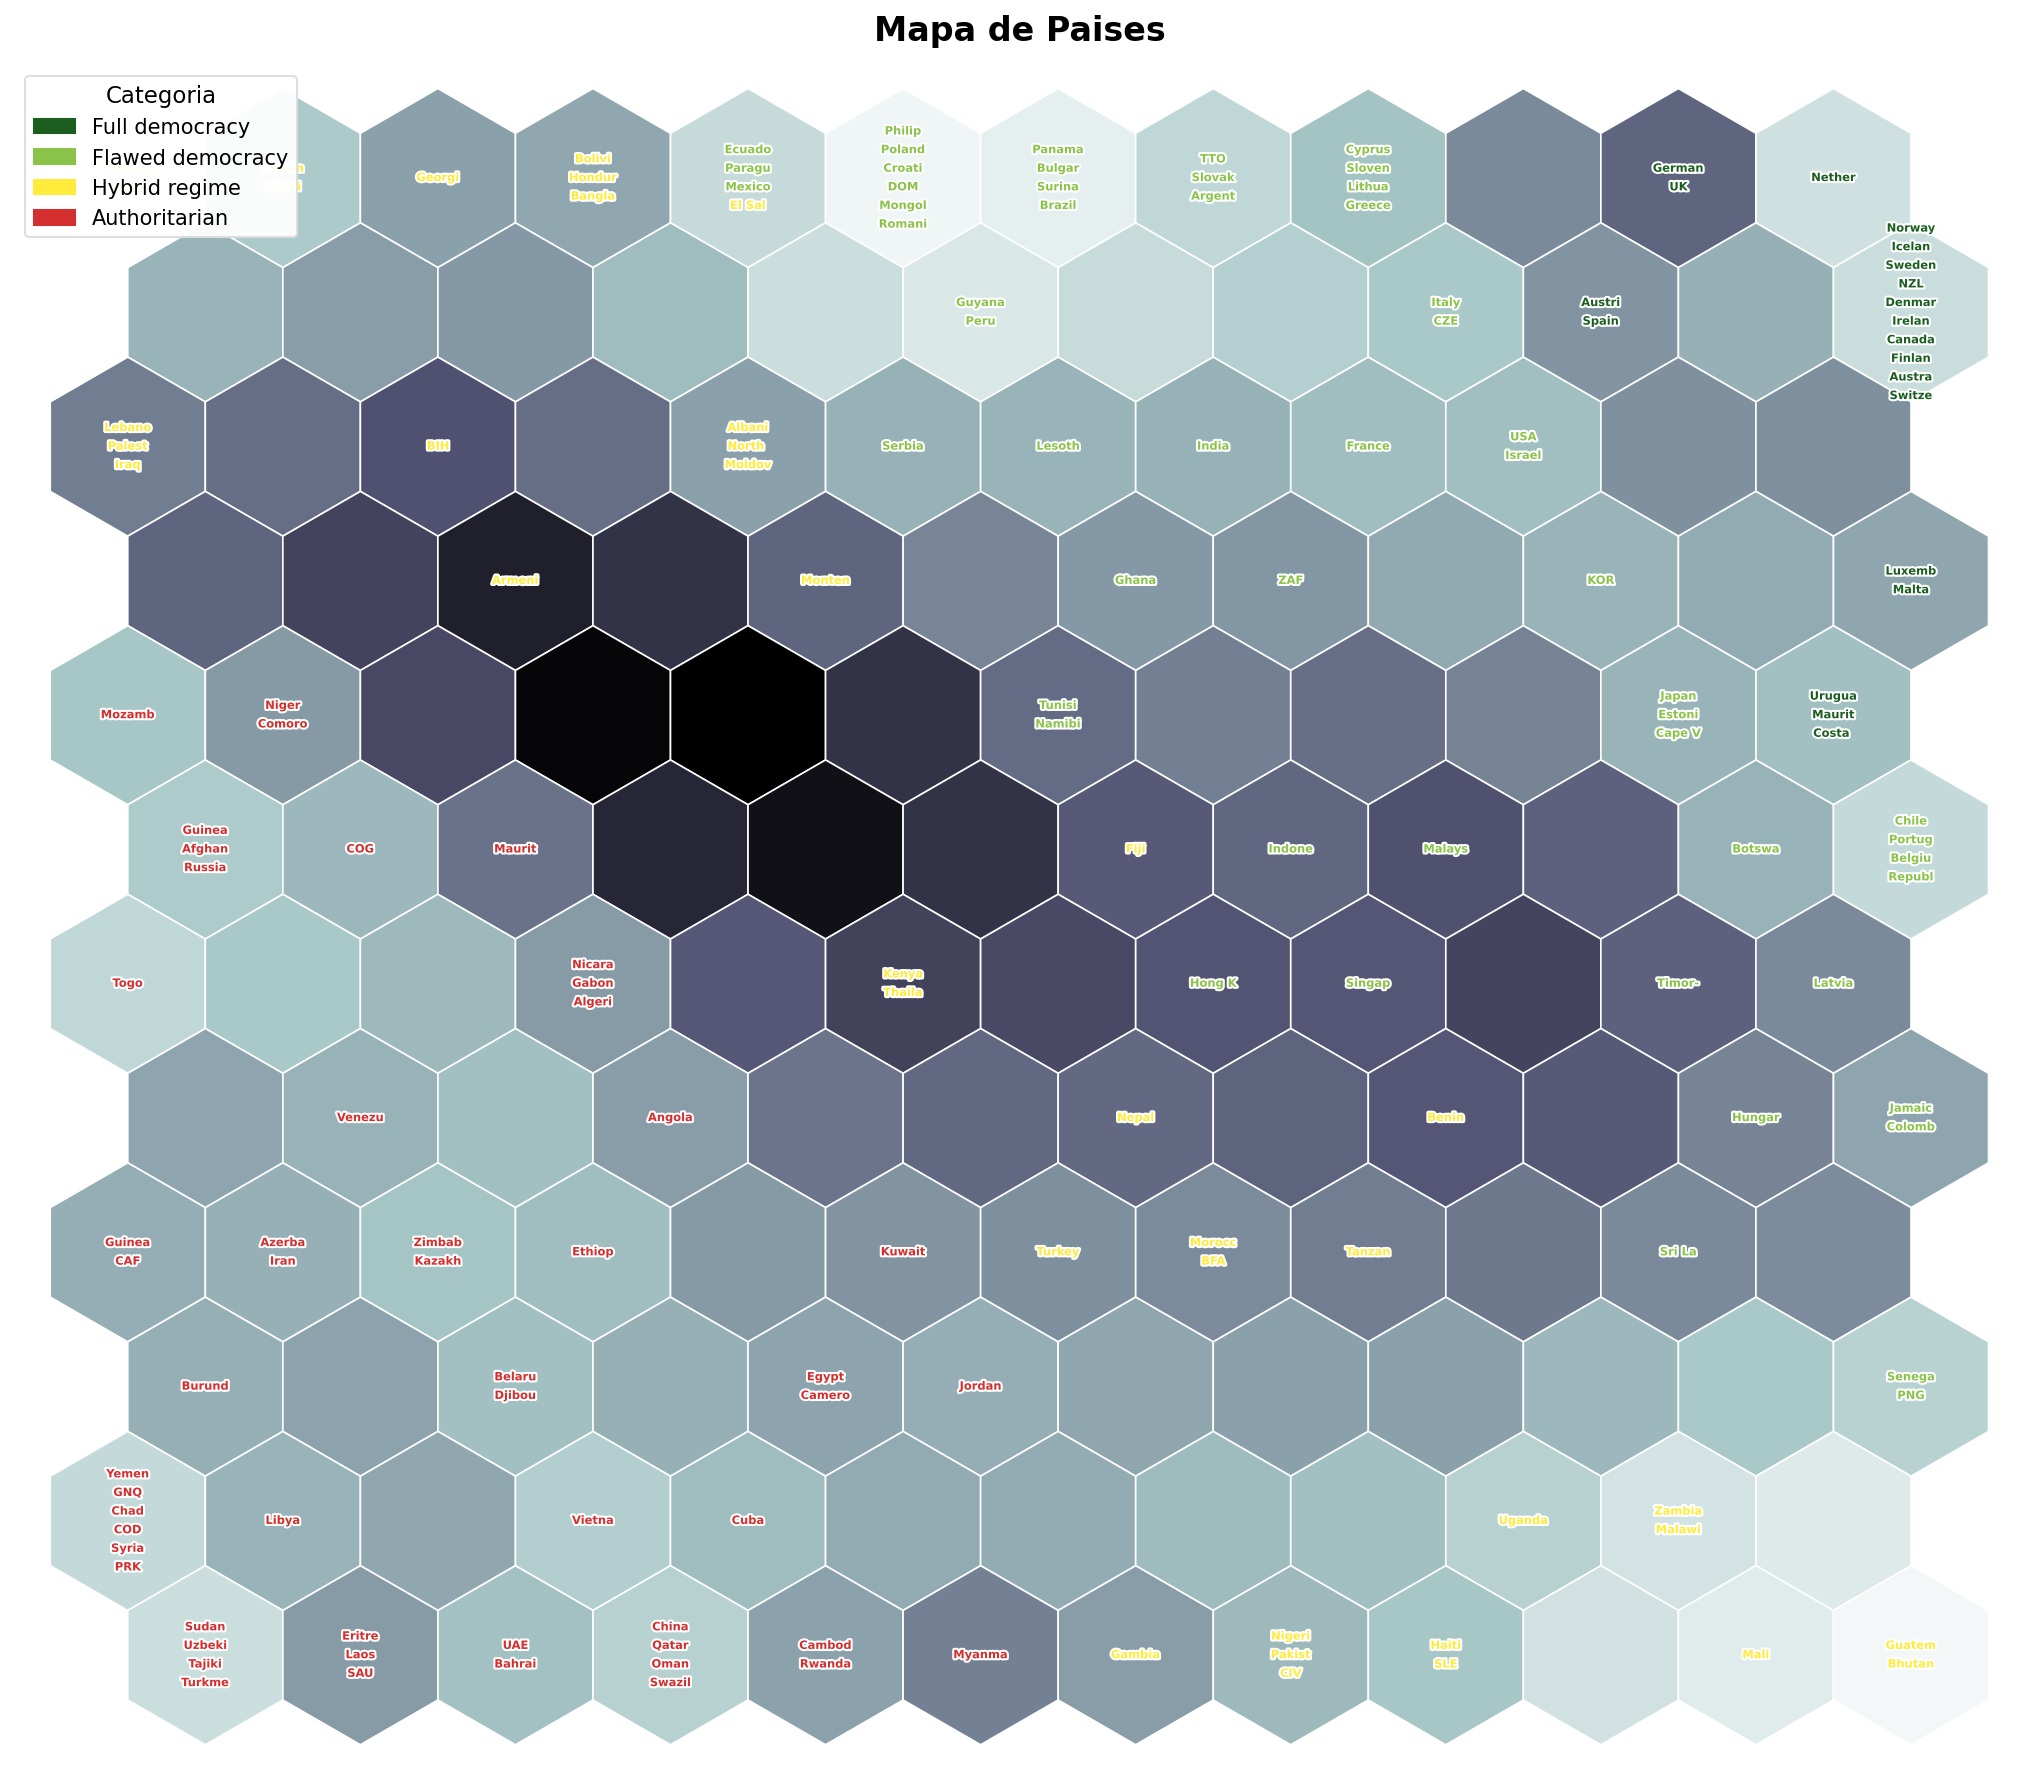

In [65]:
som.plot_winner_map(X_tensor, labels, colors_dict=colors_dict,
                    country_codes=country_codes,
                    category_color=category_color)

---
## 4. Exploração Interativa — Delimitação Manual de Clusters

O mapa interativo abaixo permite que você **desenhe diretamente sobre a U-Matrix**
para delimitar os grupos que observa visualmente.

**Instruções:**
1. Use a ferramenta **"Draw closed path"** (ícone de laço na barra superior).
2. Desenhe contornos ao redor dos agrupamentos que identificar.
3. Use **"Erase shape"** para remover.
4. Passe o mouse sobre cada célula para ver quais países estão mapeados ali.

In [67]:
try:
    import plotly
    import plotly.graph_objects as go
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'plotly', '-q'])
    import plotly
    import plotly.graph_objects as go

print(f'Plotly versao: {plotly.__version__}')

Plotly versao: 6.7.0


In [68]:
def create_interactive_umatrix(som, data, labels, colors_dict,
                               country_codes, category_color):
    """Cria U-Matrix interativa com ferramentas de desenho (Plotly)."""
    import matplotlib.colors as mcolors_conv
    umatrix = som.compute_umatrix().numpy()
    cmap = plt.cm.get_cmap('RdYlBu_r')
    norm_v = plt.Normalize(vmin=umatrix.min(), vmax=umatrix.max())

    bmus = torch.argmin(torch.cdist(data, som.weights), dim=1)
    bmu_countries = defaultdict(list)
    for idx_s, bmu in enumerate(bmus):
        bmu_countries[bmu.item()].append(labels[idx_s])

    shapes = []
    x_centers, y_centers, hover_texts = [], [], []
    R = 1.0 / np.sqrt(3)

    for k in range(som.n_neurons):
        x, y = som._neuron_xy(k)
        x_centers.append(x)
        y_centers.append(y)
        countries = bmu_countries.get(k, [])
        country_str = ", ".join(countries) if countries else "-"
        hover_texts.append(
            f'U-Matrix: {umatrix[k]:.3f}<br>Paises: {country_str}')

        if som.topology == 'hexagonal':
            angles = [np.pi / 6 + ka * np.pi / 3 for ka in range(6)]
            pts = [(x + R * np.cos(a), y + R * np.sin(a)) for a in angles]
            parts = [f'M {pts[0][0]:.6f},{pts[0][1]:.6f}']
            for px, py in pts[1:]:
                parts.append(f'L {px:.6f},{py:.6f}')
            parts.append('Z')
            path_d = ' '.join(parts)
            fcolor = mcolors_conv.to_hex(cmap(norm_v(umatrix[k])))
            shapes.append(dict(
                type='path', path=path_d, fillcolor=fcolor,
                line=dict(color='rgba(255,255,255,0.6)', width=0.8),
                layer='below'))

    fig = go.Figure()

    if som.topology == 'rectangular':
        grid = umatrix.reshape(som.m, som.n)
        hover_grid = [['' for _ in range(som.n)] for _ in range(som.m)]
        for i in range(som.m):
            for j in range(som.n):
                k = i * som.n + j
                countries = bmu_countries.get(k, [])
                country_str = ", ".join(countries) if countries else "-"
                hover_grid[i][j] = (
                    f'U-Matrix: {umatrix[k]:.3f}<br>Paises: {country_str}')
        fig.add_trace(go.Heatmap(
            z=grid, colorscale='RdYlBu_r', reversescale=True,
            text=hover_grid,
            hovertemplate='%{text}<extra></extra>',
            colorbar=dict(title='U-Matrix')))
    else:
        fig.add_trace(go.Scatter(
            x=x_centers, y=y_centers, mode='markers',
            marker=dict(size=20, opacity=0),
            text=hover_texts,
            hovertemplate='%{text}<extra></extra>',
            showlegend=False))

    # rotulos dos paises
    for k_bmu, country_list in bmu_countries.items():
        x, y = som._neuron_xy(k_bmu)
        for ki, country in enumerate(country_list):
            display = country
            if country_codes and len(country) > 6:
                display = country_codes.get(country, country[:6])
            color = colors_dict.get(country, 'black') if colors_dict else 'black'
            y_off = (ki - len(country_list) / 2 + 0.5) * 0.12
            fig.add_annotation(
                x=x, y=y + y_off,
                text=f'<b>{display}</b>', showarrow=False,
                font=dict(size=7, color=color))

    if category_color:
        for cat, color in category_color.items():
            fig.add_trace(go.Scatter(
                x=[None], y=[None], mode='markers',
                marker=dict(size=12, color=color, symbol='square'),
                name=cat, showlegend=True))

    use_shapes = shapes if som.topology == 'hexagonal' else []
    fig.update_layout(
        shapes=use_shapes,
        title=dict(text='U-Matrix Interativa — Desenhe as fronteiras!',
                   font=dict(size=16)),
        xaxis=dict(showgrid=False, zeroline=False,
                   showticklabels=False, scaleanchor='y'),
        yaxis=dict(showgrid=False, zeroline=False,
                   showticklabels=False, autorange='reversed'),
        width=900, height=800, plot_bgcolor='white',
        dragmode='drawclosedpath',
        newshape=dict(
            line=dict(color='cyan', width=3, dash='solid'),
            fillcolor='rgba(0, 255, 255, 0.08)'),
        legend=dict(x=0.01, y=0.99,
                    bgcolor='rgba(255,255,255,0.9)',
                    bordercolor='#cccccc', borderwidth=1))
    draw_buttons = ['drawline', 'drawclosedpath',
                    'drawcircle', 'drawrect', 'eraseshape']
    fig.show(config={'modeBarButtonsToAdd': draw_buttons})

create_interactive_umatrix(som, X_tensor, labels,
                           colors_dict, country_codes, category_color)

---
## 5. Agrupamento Automático — K-Means nos Pesos do SOM

Comparamos duas abordagens:
1. **Manual** — o que você delimitou no mapa interativo acima.
2. **Automática** — K-Means aplicado nos vetores de peso dos neurônios.

### Escolha do número ideal de clusters

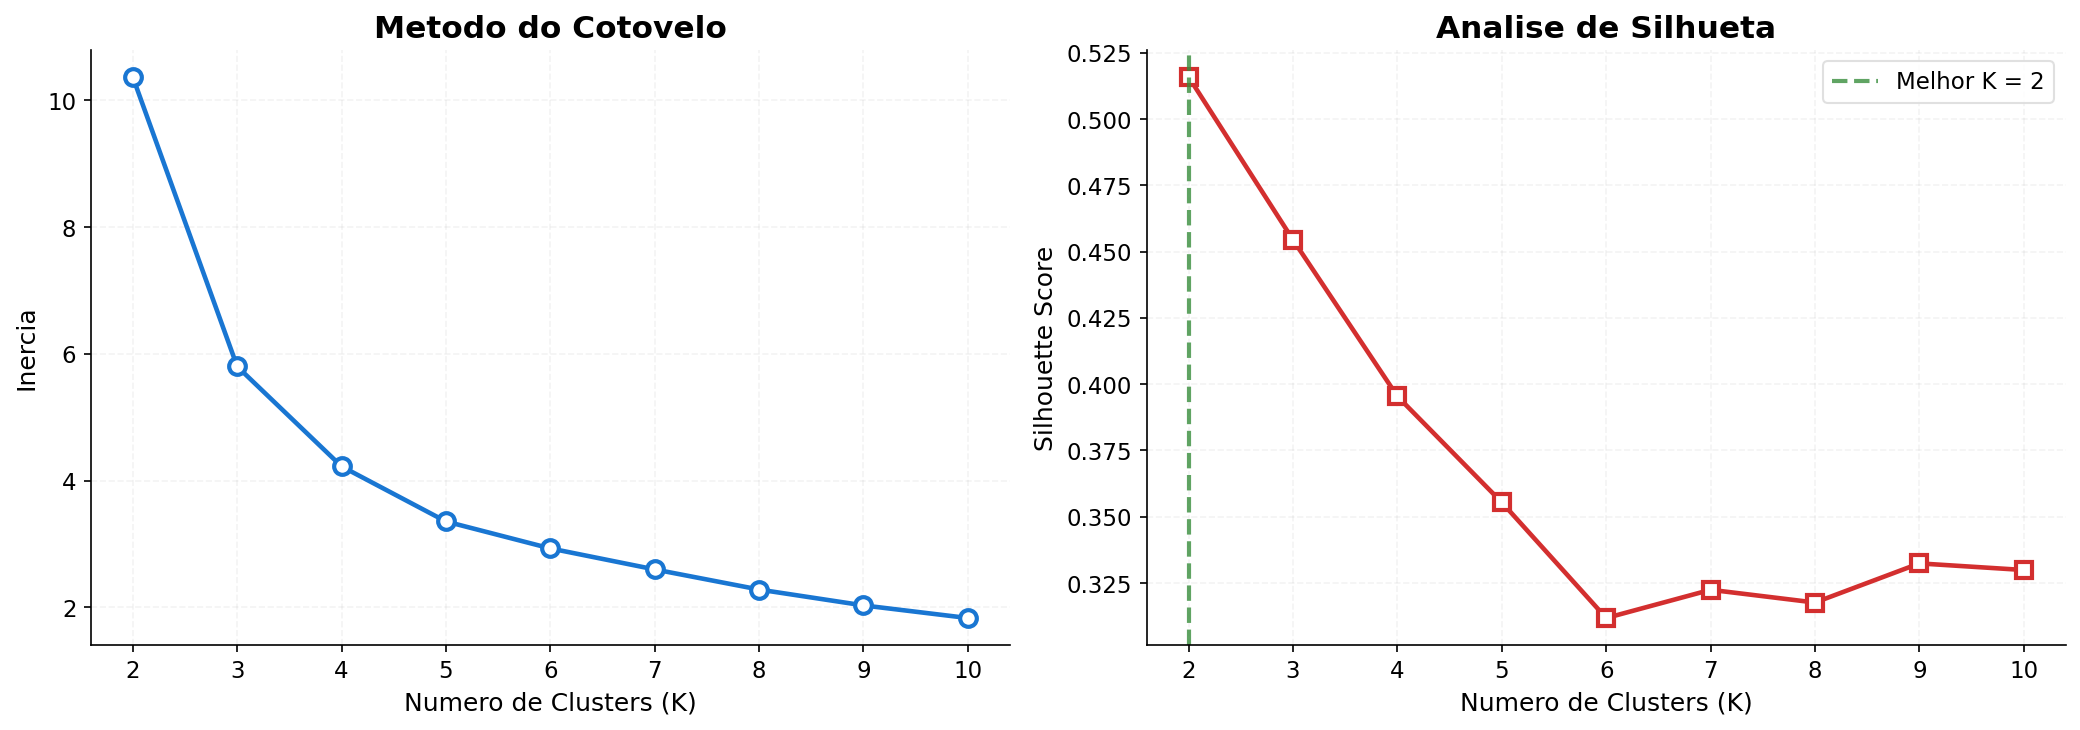

Melhor K pela Silhueta: 2


In [69]:
weights_np = som.weights.detach().numpy()
k_range = range(2, 11)
inertias, silhouettes = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    cl = km.fit_predict(weights_np)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(weights_np, cl))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(list(k_range), inertias, 'o-', color='#1976D2', linewidth=2.2,
         markersize=8, markerfacecolor='white', markeredgewidth=2)
ax1.set_title('Metodo do Cotovelo')
ax1.set_xlabel('Numero de Clusters (K)')
ax1.set_ylabel('Inercia')
ax1.grid(True, alpha=0.15, linestyle='--')

ax2.plot(list(k_range), silhouettes, 's-', color='#D32F2F', linewidth=2.2,
         markersize=8, markerfacecolor='white', markeredgewidth=2)
ax2.set_title('Analise de Silhueta')
ax2.set_xlabel('Numero de Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.grid(True, alpha=0.15, linestyle='--')

best_k = list(k_range)[np.argmax(silhouettes)]
ax2.axvline(x=best_k, color='#388E3C', linestyle='--', linewidth=2,
            alpha=0.8, label=f'Melhor K = {best_k}')
ax2.legend(fontsize=11, framealpha=0.9)

for a in (ax1, ax2):
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()
print(f'Melhor K pela Silhueta: {best_k}')

### Visualização dos Clusters

Aplicamos K-Means com **K = 4** (mesmo número de categorias do Democracy Index)
para verificar se o SOM recupera a estrutura original.
As **fronteiras escuras** indicam limites entre clusters diferentes.

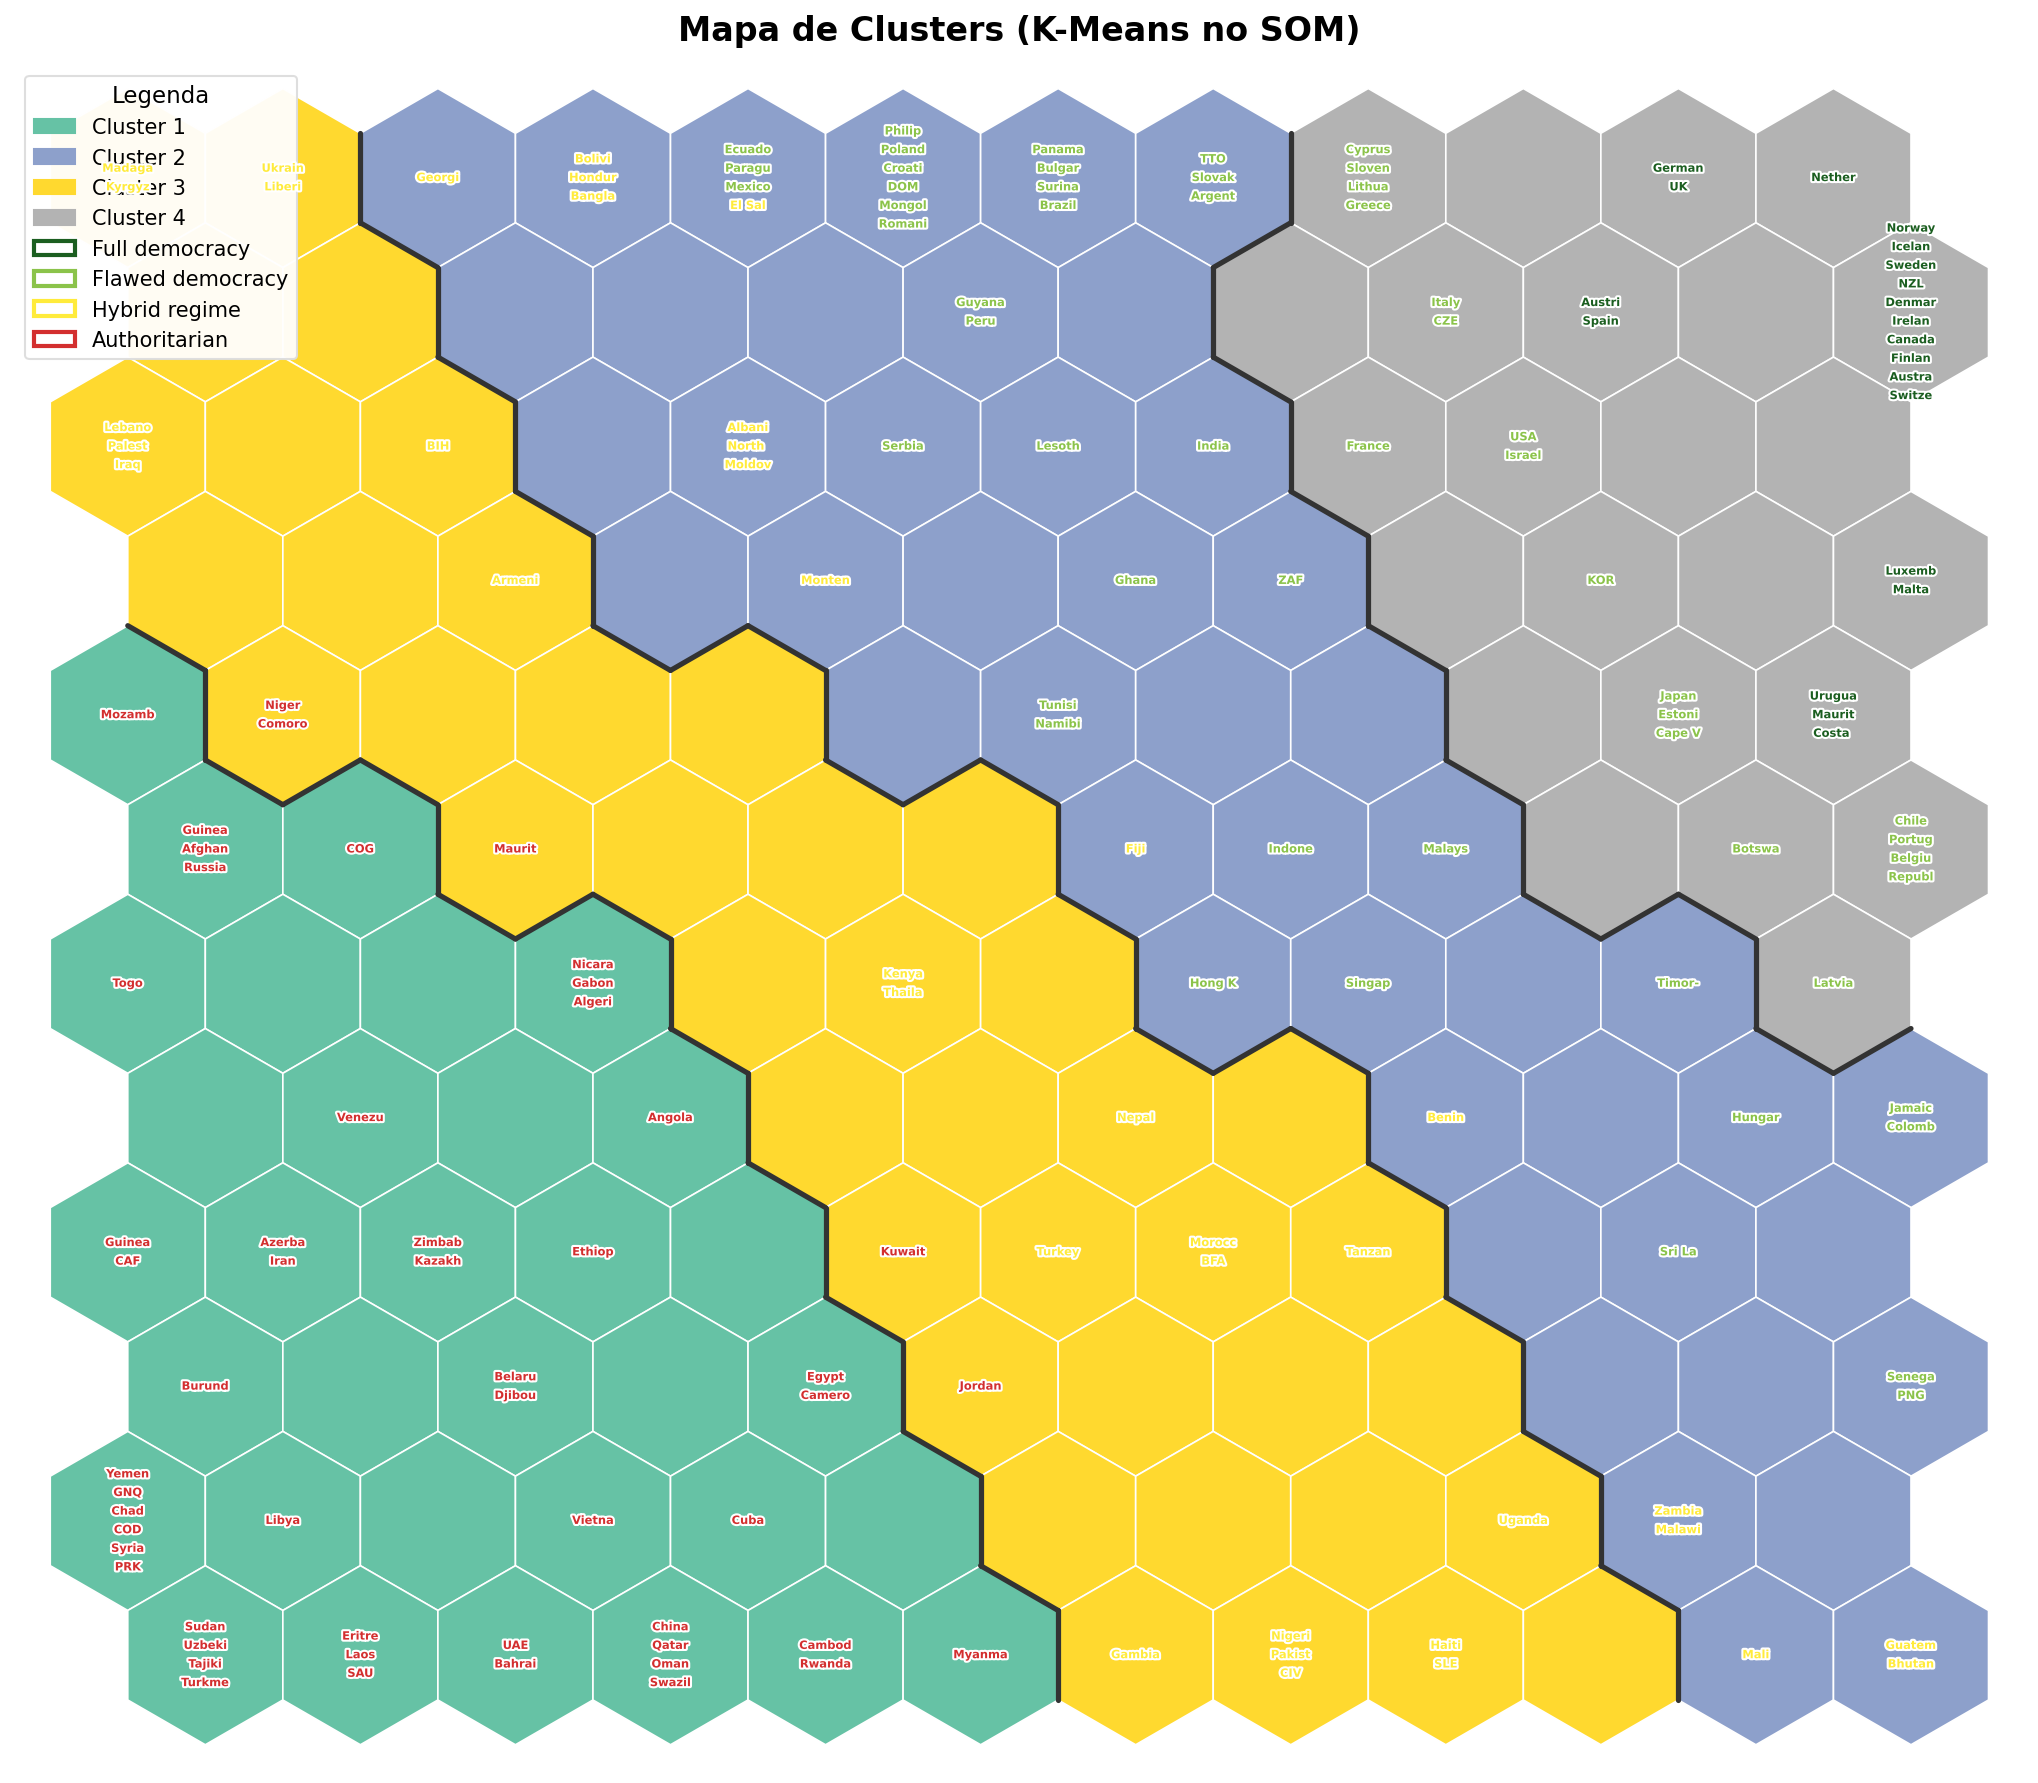

In [70]:
n_clusters = 4
km_final = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_assignments = km_final.fit_predict(weights_np)

som.plot_cluster_map(
    cluster_assignments, data=X_tensor, labels=labels,
    colors_dict=colors_dict, country_codes=country_codes,
    category_color=category_color)

### Comparação: Clusters Automáticos vs. Categorias Reais

A **pureza** de cada cluster indica a fração de países que pertence à categoria
mais representada naquele cluster.

In [71]:
dists_ct = torch.cdist(X_tensor, som.weights)
bmus_ct = torch.argmin(dists_ct, dim=1)
country_cluster = [cluster_assignments[b.item()] for b in bmus_ct]

df_comp = pd.DataFrame({
    'Pais': labels,
    'Categoria Real': democracy_index.category.values,
    'Cluster SOM': [f'Cluster {c+1}' for c in country_cluster],
})

ct = pd.crosstab(df_comp['Categoria Real'], df_comp['Cluster SOM'])
print('Tabela Cruzada: Categorias Reais vs. Clusters K-Means')
print('=' * 60)
display(ct)

print()
print('Pureza por cluster:')
print('-' * 50)
for cluster in sorted(df_comp['Cluster SOM'].unique()):
    subset = df_comp[df_comp['Cluster SOM'] == cluster]
    most_common = subset['Categoria Real'].mode()[0]
    purity = (subset['Categoria Real'] == most_common).mean()
    n_countries = len(subset)
    print(f'{cluster}: {purity:.1%} — {most_common} ({n_countries} paises)')

overall_purity = sum(
    (df_comp[df_comp['Cluster SOM'] == cl]['Categoria Real']
     == df_comp[df_comp['Cluster SOM'] == cl]['Categoria Real'].mode()[0]).sum()
    for cl in df_comp['Cluster SOM'].unique()
) / len(df_comp)
print(f'\nPureza global: {overall_purity:.1%}')

Tabela Cruzada: Categorias Reais vs. Clusters K-Means


Cluster SOM,Cluster 1,Cluster 2,Cluster 3,Cluster 4
Categoria Real,,,,
Authoritarian,48,0,5,0
Flawed democracy,0,36,0,19
Full democracy,0,0,0,20
Hybrid regime,0,16,23,0



Pureza por cluster:
--------------------------------------------------
Cluster 1: 100.0% — Authoritarian (48 paises)
Cluster 2: 69.2% — Flawed democracy (52 paises)
Cluster 3: 82.1% — Hybrid regime (28 paises)
Cluster 4: 51.3% — Full democracy (39 paises)

Pureza global: 76.0%
